In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy.stats as st
import pandas as pd

In [12]:
df = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/donkeys.csv")
x = df["Weight"]
N = np.size(x)

**Mean**

array([149.95386029, 154.16433824])

In [18]:
def bootstrap(T, data, R = 1_000, conflevel = 0.95):
    rng = np.random.default_rng()
    Ts = np.zeros(R)
    N = np.size(data)
    a = (1 - conflevel) / 2
    for r in range(R):
        idx = rng.integers(N, size = N)   
        Ts[r] = T(data[idx])
    return np.quantile(Ts, [a, 1 - a])    

In [20]:
bootstrap(np.mean, x)

array([149.99439338, 154.39926471])

In [21]:
bootstrap(np.median, x)

array([152., 158.])

In [22]:
bootstrap(np.std, x)

array([24.49565467, 28.28237091])

In [26]:
bootstrap(lambda z: np.sqrt(np.var(z)), x, conflevel = 0.98)

array([24.18437635, 28.61959558])

**Linear regression prediction**

In [27]:
def ll_regression(theta, data):
    x = data["x"]
    y = data["y"]
    b0 = theta[0]
    b1 = theta[1]
    return np.sum( (y - (b0 + b1 * x)) ** 2)

In [28]:
def ll_grad(theta, data):
    x = data["x"]
    y = data["y"]
    b0 = theta[0]
    b1 = theta[1]
    lm = b0 + b1 * x
    db0 = np.sum(y - lm)
    db1 = np.sum( x * (y - lm) )
    return -2 * np.array([db0, db1])

In [38]:
rng = np.random.default_rng()
init = rng.normal(size = 2)
d = {
    "x": df["Height"],
    "y": df["Weight"]
}
o = minimize(ll_regression, init, jac = ll_grad, args = (d,))

In [30]:
o.x

array([-309.30049357,    4.55262576])

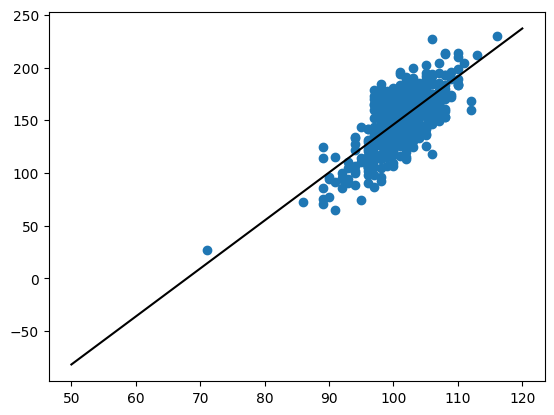

In [34]:
plt.scatter(df["Height"], df["Weight"])
y0 = np.sum(o.x * np.array([1, 50]))
y1 = np.sum(o.x * np.array([1, 120]))
plt.plot(np.array([50, 120]), np.array([y0, y1]), color = "black");

In [43]:
# work in progress
R = 1_000
def bootstrap2(T, data, R = 1_000, conflevel = 0.95):
    ws = np.zeros(R)
    rng = np.random.default_rng()
    for r in range(R):
        init = rng.normal(size = 2)
        idx = rng.integers(N, size = N)
        d = {
            "x": df["Height"][idx],
            "y": df["Weight"][idx]
        }
        o = minimize(ll_regression, init, jac = ll_grad, args = (d,))
        ws[r] = np.sum(o.x * np.array([1, 80]))
    return np.quantile(ws, [0.025, 0.975])


array([46.46930597, 63.17156952])

In [39]:
np.sum(o.x * np.array([1, 80]))

54.909567021620944

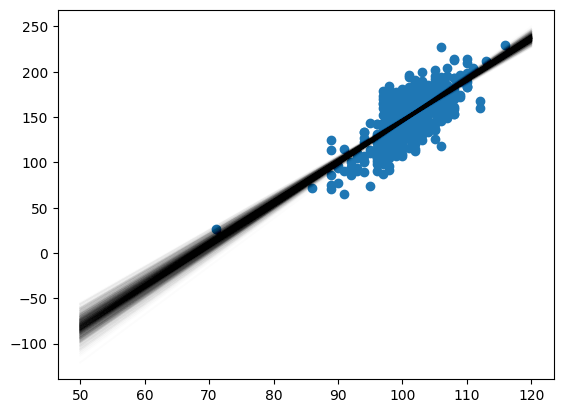

In [46]:
plt.scatter(df["Height"], df["Weight"])
for r in range(R):
    y0 = np.sum(coefs[r] * np.array([1, 50]))
    y1 = np.sum(coefs[r] * np.array([1, 120]))
    plt.plot(np.array([50, 120]), np.array([y0, y1]), color = "black", alpha = 0.01);